# Pushshift Baseline: TF-IDF + Logistic Regression

This notebook implements the TF-IDF + Logistic Regression baseline for the Pushshift Reddit pipeline under the unified project structure.

It is designed to:
- load the processed Reddit dataset from `Dataset/pushshift/`
- align paths with the shared `Code/artifacts/pushshift/` layout
- train a three-class TF-IDF + Logistic Regression baseline
- save reusable experiment artifacts for later comparison with LSTM and BERT models
- export evaluation outputs that can support later thesis writing


## 0. Environment Setup and Dependency Check

This section verifies the core packages required for the baseline experiment. Running it first helps reduce import-related errors and keeps the notebook reproducible across different environments.


In [1]:
import importlib
import subprocess
import sys


def install_if_missing(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"✅ {package_name} is already available")
    except ImportError:
        print(f"⬇️ Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


required_packages = [
    ("numpy", None),
    ("pandas", None),
    ("scikit-learn", "sklearn"),
    ("matplotlib", None),
    ("seaborn", None),
    ("joblib", None),
]

for package_name, import_name in required_packages:
    install_if_missing(package_name, import_name)


✅ numpy is already available
✅ pandas is already available
✅ scikit-learn is already available
✅ matplotlib is already available
✅ seaborn is already available
✅ joblib is already available


## 1. Resolve Project Paths and Load the Pushshift Dataset

The notebook follows the same directory logic as the Sentiment140 baseline.  
This makes the Reddit pipeline easier to maintain and ensures that all exported files are saved to predictable locations under the project root.


In [2]:
from pathlib import Path
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROJECT_ROOT = CODE_DIR.parent

DATASET_DIR = PROJECT_ROOT / "Dataset" / "pushshift"
ARTIFACT_DIR = CODE_DIR / "artifacts" / "pushshift"
MODEL_DIR = ARTIFACT_DIR / "models"
PREDICTION_DIR = ARTIFACT_DIR / "predictions"
SPLIT_DIR = ARTIFACT_DIR / "splits"
CONFIG_DIR = ARTIFACT_DIR / "config"
FIGURE_DIR = ARTIFACT_DIR / "figures"
RESULT_DIR = ARTIFACT_DIR / "results"

for path in [MODEL_DIR, PREDICTION_DIR, SPLIT_DIR, CONFIG_DIR, FIGURE_DIR, RESULT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATASET_DIR / "reddit_vader_dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Dataset path:", DATA_PATH)
df.head()


Dataset shape: (30000, 6)
Dataset path: /Users/victor/Desktop/Graduation_Thesis/Dataset/pushshift/reddit_vader_dataset.csv


,text,label,score,subreddit,created_utc,label_name
0,![gif](giphy|mFYTaY7Gth86xnE6N5),1,0.0000,MadeMeSmile,1640995203,neutral
1,Dayvon the boulder johnson.,1,0.0000,MadeMeSmile,1640995209,neutral
2,Congrats!! That's awesome!!,2,0.8647,MadeMeSmile,1640995213,positive
3,"As someone who has never been homeless, I can ...",0,-0.5423,MadeMeSmile,1640995213,negative
4,Congrats u f’ing legend!!!,2,0.6458,MadeMeSmile,1640995214,positive


## 2. Inspect the Raw Dataset

Before training the baseline, it is useful to confirm the available columns and the class balance.  
This quick inspection also makes it easier to verify that the Reddit dataset matches the expected three-class setup.


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

if "subreddit" in df.columns:
    print("\nSubreddit distribution:")
    print(df["subreddit"].value_counts())


Columns:
['text', 'label', 'score', 'subreddit', 'created_utc', 'label_name']

Label distribution:
label
0     7300
1     7301
2    15399
Name: count, dtype: int64

Subreddit distribution:
subreddit
MadeMeSmile    10000
depression     10000
AskReddit      10000
Name: count, dtype: int64


## 3. Apply Basic Data Quality Checks

Although the dataset was prepared in an earlier notebook, a lightweight cleaning pass is still helpful here.  
The goal is not to redesign preprocessing, but to remove missing, empty, and duplicate records before vectorisation.


In [4]:
print("Missing values by column:")
print(df.isnull().sum())

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""]
df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

print("\nCleaned dataset shape:", df.shape)
df.head()


Missing values by column:
text           0
label          0
score          0
subreddit      0
created_utc    0
label_name     0
dtype: int64

Cleaned dataset shape: (29032, 6)


,text,label,score,subreddit,created_utc,label_name
0,![gif](giphy|mFYTaY7Gth86xnE6N5),1,0.0000,MadeMeSmile,1640995203,neutral
1,Dayvon the boulder johnson.,1,0.0000,MadeMeSmile,1640995209,neutral
2,Congrats!! That's awesome!!,2,0.8647,MadeMeSmile,1640995213,positive
3,"As someone who has never been homeless, I can ...",0,-0.5423,MadeMeSmile,1640995213,negative
4,Congrats u f’ing legend!!!,2,0.6458,MadeMeSmile,1640995214,positive


## 4. Create Fixed 60/10/30 Stratified Splits

The Reddit dataset is split into train, validation, and test sets using the same 60/10/30 design as the Sentiment140 experiments.  
Stratification keeps the label ratio broadly stable across the three splits.


In [5]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

split_source = df.copy()

train_df, temp_df = train_test_split(
    split_source,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=split_source["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.75,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (17419, 6)
Validation shape: (2903, 6)
Test shape: (8710, 6)


In [6]:
for split_name, split_df in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():
    print(f"\n{split_name} label distribution:")
    print(split_df["label"].value_counts(normalize=True).sort_index())



Train label distribution:
label
0    0.249957
1    0.238303
2    0.511740
Name: proportion, dtype: float64

Validation label distribution:
label
0    0.249742
1    0.238374
2    0.511884
Name: proportion, dtype: float64

Test label distribution:
label
0    0.249943
1    0.238347
2    0.511711
Name: proportion, dtype: float64


## 5. Train the TF-IDF + Logistic Regression Baseline

This baseline uses unigram and bigram TF-IDF features together with Logistic Regression.  
The configuration remains intentionally simple so that later improvements from neural and transformer models can be discussed more clearly.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_train = train_df["text"]
y_train = train_df["label"]
X_val = val_df["text"]
y_val = val_df["label"]
X_test = test_df["text"]
y_test = test_df["label"]

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

tfidf_lr.fit(X_train, y_train)
print("Training finished.")


Training finished.


## 6. Evaluate the Baseline Model

The model is checked on both the validation split and the held-out test split.  
Accuracy and per-class precision, recall, and F1-score are reported to show how well the baseline handles the negative, neutral, and positive labels.


In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_val_pred = tfidf_lr.predict(X_val)
y_test_pred = tfidf_lr.predict(X_test)

y_val_proba = tfidf_lr.predict_proba(X_val)
y_test_proba = tfidf_lr.predict_proba(X_test)
class_order = tfidf_lr.named_steps["clf"].classes_.tolist()

print("Validation Accuracy:", round(accuracy_score(y_val, y_val_pred), 4))
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

print("\nTest Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))


Validation Accuracy: 0.7699

Validation Classification Report:
              precision    recall  f1-score   support

           0     0.6658    0.7172    0.6906       725
           1     0.6916    0.8295    0.7543       692
           2     0.8831    0.7678    0.8215      1486

    accuracy                         0.7699      2903
   macro avg     0.7468    0.7715    0.7554      2903
weighted avg     0.7832    0.7699    0.7728      2903


Test Accuracy: 0.7642

Test Classification Report:
              precision    recall  f1-score   support

           0     0.6687    0.7083    0.6879      2177
           1     0.6776    0.8382    0.7494      2076
           2     0.8796    0.7570    0.8137      4457

    accuracy                         0.7642      8710
   macro avg     0.7419    0.7678    0.7503      8710
weighted avg     0.7787    0.7642    0.7669      8710



## 7. Visualise the Test Confusion Matrix

A confusion matrix gives a compact view of where the model succeeds and where it confuses neighbouring sentiment classes.  
This is especially useful for the Reddit dataset, where the neutral class can be more difficult than the strongly positive or negative classes.


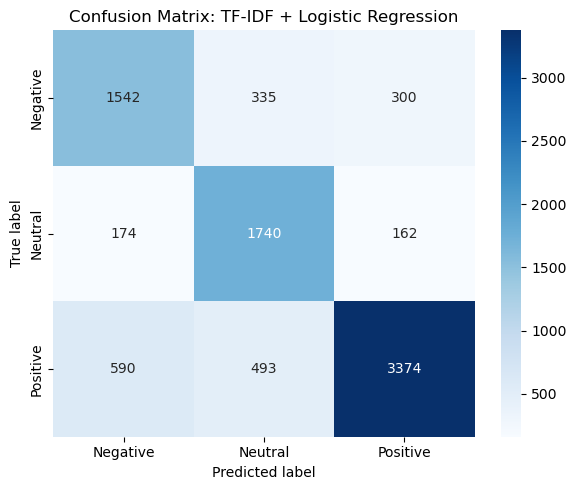

Saved figure to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/figures/tfidf_lr_confusion_matrix.png


In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

label_order = sorted(df["label"].unique())
label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

cm = confusion_matrix(y_test, y_test_pred, labels=label_order)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[label_names.get(label, str(label)) for label in label_order],
    yticklabels=[label_names.get(label, str(label)) for label in label_order]
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.tight_layout()

figure_path = FIGURE_DIR / "tfidf_lr_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", figure_path)


## 8. Save Reusable Artifacts

This section saves the trained pipeline, fixed split files, test predictions, and a compact experiment configuration.  
These outputs can be reused directly in later comparison notebooks and in the thesis evaluation chapter.



In [10]:
import json
import joblib

split_columns = [col for col in ["text", "label", "subreddit", "created_utc", "compound"] if col in train_df.columns]

train_df[split_columns].to_csv(SPLIT_DIR / "train_60.csv", index=False)
val_df[split_columns].to_csv(SPLIT_DIR / "val_10.csv", index=False)
test_df[split_columns].to_csv(SPLIT_DIR / "test_30.csv", index=False)

pred_test_df = test_df.copy()
pred_test_df["pred_label"] = y_test_pred

if len(class_order) == 3:
    pred_test_df["prob_negative"] = y_test_proba[:, class_order.index(0)]
    pred_test_df["prob_neutral"] = y_test_proba[:, class_order.index(1)]
    pred_test_df["prob_positive"] = y_test_proba[:, class_order.index(2)]

pred_test_df["label_name"] = pred_test_df["label"].map({0: "negative", 1: "neutral", 2: "positive"})
pred_test_df["pred_label_name"] = pred_test_df["pred_label"].map({0: "negative", 1: "neutral", 2: "positive"})
pred_test_df.to_csv(PREDICTION_DIR / "pred_test_tfidf_lr.csv", index=False)

joblib.dump(tfidf_lr, MODEL_DIR / "tfidf_lr_model.joblib")

config = {
    "dataset_name": "pushshift_reddit_vader",
    "task": "three_class_sentiment_classification",
    "model": "tfidf_logistic_regression",
    "random_state": RANDOM_STATE,
    "split_ratio": {"train": 0.60, "val": 0.10, "test": 0.30},
    "tfidf": {
        "max_features": 20000,
        "ngram_range": [1, 2],
        "min_df": 5
    },
    "classifier": {
        "type": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "balanced"
    },
    "paths": {
        "dataset": str(DATA_PATH),
        "train_split": str(SPLIT_DIR / "train_60.csv"),
        "val_split": str(SPLIT_DIR / "val_10.csv"),
        "test_split": str(SPLIT_DIR / "test_30.csv"),
        "test_predictions": str(PREDICTION_DIR / "pred_test_tfidf_lr.csv"),
        "model": str(MODEL_DIR / "tfidf_lr_model.joblib"),
        "confusion_matrix_figure": str(FIGURE_DIR / "tfidf_lr_confusion_matrix.png"),
        "result_dir": str(RESULT_DIR)
    }
}

with open(CONFIG_DIR / "tfidf_lr_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Saved splits to:", SPLIT_DIR)
print("Saved predictions to:", PREDICTION_DIR)
print("Saved model to:", MODEL_DIR)
print("Saved config to:", CONFIG_DIR)
print("Result directory:", RESULT_DIR)


Saved splits to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/splits
Saved predictions to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/predictions
Saved model to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/models
Saved config to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/config
Result directory: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/results


## 9. Construct a Temporal Happiness Index

Unlike Sentiment140, the Pushshift Reddit dataset retains `created_utc`, so the baseline can be extended from sample-level sentiment prediction to time-aware aggregation.  
This section builds an overall happiness index and a temporal version grouped by an automatically selected time window.

The index is defined in two complementary ways:
- **label-based HI:** map predicted classes to `{-1, 0, +1}` for negative, neutral, and positive
- **probability-based HI:** compute `p(positive) - p(negative)` for each comment and average within a time window

To make later comparison easier, both indices are reported on the raw `[-1, 1]` scale and on a mapped `0-100` scale.



In [15]:
import json
import numpy as np
import pandas as pd

label_to_score = {0: -1, 1: 0, 2: 1}

hi_df = pred_test_df.copy()

if "created_utc" not in hi_df.columns:
    raise ValueError("`created_utc` is required to construct the temporal happiness index for Pushshift.")

# Parse timestamps robustly
if pd.api.types.is_numeric_dtype(hi_df["created_utc"]):
    hi_df["created_dt"] = pd.to_datetime(hi_df["created_utc"], unit="s", utc=True, errors="coerce")
else:
    hi_df["created_dt"] = pd.to_datetime(hi_df["created_utc"], utc=True, errors="coerce")

hi_df = hi_df.dropna(subset=["created_dt"]).copy()
hi_df = hi_df.sort_values("created_dt").reset_index(drop=True)

if hi_df.empty:
    raise ValueError("No valid timestamps were available after parsing `created_utc`.")

# Comment-level happiness scores
hi_df["score_label_3class"] = hi_df["pred_label"].map(label_to_score)

if {"prob_positive", "prob_negative"}.issubset(hi_df.columns):
    hi_df["score_prob_continuous"] = hi_df["prob_positive"] - hi_df["prob_negative"]
else:
    hi_df["score_prob_continuous"] = np.nan

# Choose temporal window automatically
time_span_days = (hi_df["created_dt"].max() - hi_df["created_dt"].min()).days

if time_span_days >= 90:
    temporal_window = "month"
    hi_df["time_window"] = hi_df["created_dt"].dt.to_period("M").astype(str)
elif time_span_days >= 28:
    temporal_window = "week"
    hi_df["time_window"] = hi_df["created_dt"].dt.to_period("W-MON").astype(str)
else:
    temporal_window = "day"
    hi_df["time_window"] = hi_df["created_dt"].dt.strftime("%Y-%m-%d")


def ratio(series, value):
    return float((series == value).mean())


def safe_mean(series):
    s = pd.to_numeric(series, errors="coerce")
    return float(s.mean()) if s.notna().any() else np.nan


# Overall summary
overall_summary = {
    "dataset": "pushshift",
    "model": "tfidf_lr",
    "index_variant": "overall_temporal_ready",
    "sample_size": int(len(hi_df)),
    "time_span_days": int(time_span_days),
    "temporal_window": temporal_window,
    "n_time_windows": int(hi_df["time_window"].nunique()),
    "negative_ratio": ratio(hi_df["pred_label"], 0),
    "neutral_ratio": ratio(hi_df["pred_label"], 1),
    "positive_ratio": ratio(hi_df["pred_label"], 2),
    "mean_prob_negative": safe_mean(hi_df["prob_negative"]) if "prob_negative" in hi_df.columns else np.nan,
    "mean_prob_neutral": safe_mean(hi_df["prob_neutral"]) if "prob_neutral" in hi_df.columns else np.nan,
    "mean_prob_positive": safe_mean(hi_df["prob_positive"]) if "prob_positive" in hi_df.columns else np.nan,
    "hi_label_raw": safe_mean(hi_df["score_label_3class"]),
    "hi_label_100": float(50 * (safe_mean(hi_df["score_label_3class"]) + 1)),
    "hi_prob_raw": safe_mean(hi_df["score_prob_continuous"]),
    "hi_prob_100": float(50 * (safe_mean(hi_df["score_prob_continuous"]) + 1)) if hi_df["score_prob_continuous"].notna().any() else np.nan,
}

# Temporal aggregation without groupby.apply
temporal_rows = []

for time_window, g in hi_df.groupby("time_window", sort=False):
    row = {
        "time_window": time_window,
        "time_window_start": g["created_dt"].min().strftime("%Y-%m-%d"),
        "sample_size": int(len(g)),
        "negative_ratio": ratio(g["pred_label"], 0),
        "neutral_ratio": ratio(g["pred_label"], 1),
        "positive_ratio": ratio(g["pred_label"], 2),
        "mean_prob_negative": safe_mean(g["prob_negative"]) if "prob_negative" in g.columns else np.nan,
        "mean_prob_neutral": safe_mean(g["prob_neutral"]) if "prob_neutral" in g.columns else np.nan,
        "mean_prob_positive": safe_mean(g["prob_positive"]) if "prob_positive" in g.columns else np.nan,
        "hi_label_raw": safe_mean(g["score_label_3class"]),
        "hi_label_100": float(50 * (safe_mean(g["score_label_3class"]) + 1)),
        "hi_prob_raw": safe_mean(g["score_prob_continuous"]),
        "hi_prob_100": float(50 * (safe_mean(g["score_prob_continuous"]) + 1)) if g["score_prob_continuous"].notna().any() else np.nan,
    }
    temporal_rows.append(row)

temporal_hi_df = pd.DataFrame(temporal_rows).sort_values("time_window_start").reset_index(drop=True)

# Subreddit + temporal aggregation without groupby.apply
subreddit_temporal_hi_df = pd.DataFrame()

if "subreddit" in hi_df.columns:
    subreddit_rows = []

    for (subreddit, time_window), g in hi_df.groupby(["subreddit", "time_window"], sort=False):
        row = {
            "subreddit": subreddit,
            "time_window": time_window,
            "time_window_start": g["created_dt"].min().strftime("%Y-%m-%d"),
            "sample_size": int(len(g)),
            "negative_ratio": ratio(g["pred_label"], 0),
            "neutral_ratio": ratio(g["pred_label"], 1),
            "positive_ratio": ratio(g["pred_label"], 2),
            "hi_label_raw": safe_mean(g["score_label_3class"]),
            "hi_label_100": float(50 * (safe_mean(g["score_label_3class"]) + 1)),
            "hi_prob_raw": safe_mean(g["score_prob_continuous"]),
            "hi_prob_100": float(50 * (safe_mean(g["score_prob_continuous"]) + 1)) if g["score_prob_continuous"].notna().any() else np.nan,
        }
        subreddit_rows.append(row)

    subreddit_temporal_hi_df = (
        pd.DataFrame(subreddit_rows)
        .sort_values(["subreddit", "time_window_start"])
        .reset_index(drop=True)
    )

# Save results
overall_summary_df = pd.DataFrame([overall_summary])

overall_summary_df.to_csv(RESULT_DIR / "tfidf_lr_happiness_index_summary.csv", index=False)
temporal_hi_df.to_csv(RESULT_DIR / "tfidf_lr_temporal_happiness_index.csv", index=False)

if not subreddit_temporal_hi_df.empty:
    subreddit_temporal_hi_df.to_csv(
        RESULT_DIR / "tfidf_lr_subreddit_temporal_happiness_index.csv",
        index=False
    )

with open(RESULT_DIR / "tfidf_lr_happiness_index_overall.json", "w", encoding="utf-8") as f:
    json.dump(overall_summary, f, ensure_ascii=False, indent=2)

print("Selected temporal window:", temporal_window)
print("Time span (days):", time_span_days)
print("Number of windows:", hi_df["time_window"].nunique())

print("\nOverall happiness index summary:")
display(overall_summary_df)

print("\nTemporal happiness index preview:")
display(temporal_hi_df.head())

if not subreddit_temporal_hi_df.empty:
    print("\nSubreddit-level temporal happiness index preview:")
    display(subreddit_temporal_hi_df.head())

Selected temporal window: day
Time span (days): 8
Number of windows: 9

Overall happiness index summary:


,dataset,model,index_variant,sample_size,time_span_days,temporal_window,n_time_windows,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,pushshift,tfidf_lr,overall_temporal_ready,8710,8,day,9,0.264753,0.294834,0.440413,0.296638,0.275566,0.427796,0.17566,58.783008,0.131158,56.557894



Temporal happiness index preview:


,time_window,time_window_start,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,2022-01-01,2022-01-01,6091,0.212280,0.365457,0.422262,0.256952,0.327898,0.415150,0.209982,60.499097,0.158197,57.909874
1,2022-01-02,2022-01-02,339,0.359882,0.153392,0.486726,0.380192,0.164247,0.455562,0.126844,56.342183,0.075370,53.768490
2,2022-01-03,2022-01-03,345,0.402899,0.147826,0.449275,0.393904,0.161336,0.444761,0.046377,52.318841,0.050857,52.542837
3,2022-01-04,2022-01-04,361,0.398892,0.110803,0.490305,0.398550,0.138293,0.463157,0.091413,54.570637,0.064608,53.230388
4,2022-01-05,2022-01-05,339,0.365782,0.150442,0.483776,0.375800,0.176405,0.447796,0.117994,55.899705,0.071996,53.599813



Subreddit-level temporal happiness index preview:


,subreddit,time_window,time_window_start,sample_size,negative_ratio,neutral_ratio,positive_ratio,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,AskReddit,2022-01-01,2022-01-01,2823,0.273468,0.470776,0.255756,-0.017712,49.114417,-0.008729,49.563526
1,MadeMeSmile,2022-01-01,2022-01-01,2880,0.134375,0.296181,0.569444,0.435069,71.753472,0.321514,66.075685
2,depression,2022-01-01,2022-01-01,388,0.345361,0.113402,0.541237,0.195876,59.793814,0.160476,58.023809
3,depression,2022-01-02,2022-01-02,339,0.359882,0.153392,0.486726,0.126844,56.342183,0.075370,53.768490
4,depression,2022-01-03,2022-01-03,345,0.402899,0.147826,0.449275,0.046377,52.318841,0.050857,52.542837


## 10. Inspect Misclassified Examples

A small qualitative error table can be helpful when discussing the limitations of the baseline model.  
Typical failure cases may include sarcasm, context-heavy comments, or emotionally mixed statements.



In [16]:
error_df = test_df.copy()
error_df["pred_label"] = y_test_pred
error_df = error_df[error_df["label"] != error_df["pred_label"]].reset_index(drop=True)

print("Number of misclassified examples:", len(error_df))
error_df.head(20)


Number of misclassified examples: 2054


,text,label,score,subreddit,created_utc,label_name,pred_label
0,Rhinoceroses. How is it that we have invented...,2,0.0772,AskReddit,1640996565,positive,0
1,I know and people will say “ someone always ha...,2,0.1531,depression,1641343764,positive,0
2,Did you apologize and ask for forgiveness? Did...,2,0.9268,depression,1641511919,positive,0
3,It really is sad to hear that your being compa...,2,0.8328,depression,1641669219,positive,0
4,Congratulations and keep it up! I've been home...,2,0.9083,MadeMeSmile,1641011100,positive,0
5,Remember that your parents werent bork already...,2,0.0772,depression,1641092016,positive,0
6,Survive. And hopefully get a full time job in ...,2,0.4019,AskReddit,1640996952,positive,1
7,Mosquitos. Do they serve any greater purpose i...,2,0.6239,AskReddit,1641000146,positive,1
8,Holy shitballs yes. I think of how far I’ve co...,2,0.4019,MadeMeSmile,1641019273,positive,0
9,Congratulations! Thats major!\n\n![gif](giphy|...,2,0.6981,MadeMeSmile,1641004326,positive,1
